In [1]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_groq import ChatGroq
from dotenv import load_dotenv

load_dotenv()


c:\Users\Ashutosh Pandey\Desktop\Machine Learning\LangGraph-In-Depth\LangGraph\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0.4)

In [3]:
def create_node(state: MessagesState):
    response = llm.invoke(state['messages'])
    return {"messages": [response]}

In [4]:
# building the graph
graph = StateGraph(MessagesState)

graph.add_node("create_node", create_node)
graph.add_edge(START, "create_node")
graph.add_edge("create_node", END)

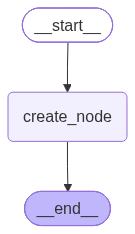

In [5]:
graph.compile()